In [3]:
import torch
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from torch import nn
from torch import optim
from torchvision.datasets import ImageFolder

In [4]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])]) ## Precalculated for mobileNet

In [5]:
train_dataset=ImageFolder(root='D:\\dataset\\train', transform=transform)
test_dataset=ImageFolder(root='D:\\dataset\\test', transform=transform)

In [6]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32,shuffle=False)

In [7]:
print(train_dataset.classes)
print(f"Train size: {len(train_dataset)}, Test size: {len(test_dataset)}")

['normal', 'pneumonia']
Train size: 640, Test size: 160


In [11]:
from torchvision import models
model2 = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

In [12]:
for param in model2.features.parameters():
    param.requires_grad = False

In [13]:
model2.classifier[1]=nn.Linear(1280,2)

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model2.parameters(),lr=0.001)

In [15]:
num_epochs = 10

for epoch in range(num_epochs):

    running_loss = 0.0

    for images, labels in train_loader:

        # Forward pass
        outputs = model2(images)

        loss = criterion(outputs, labels)

        # Clear old gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()
        
    #epoch_loss = running_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss:.4f}")

Epoch [1/10], Loss: 11.6544
Epoch [2/10], Loss: 8.6142
Epoch [3/10], Loss: 7.4646
Epoch [4/10], Loss: 6.8428
Epoch [5/10], Loss: 6.5409
Epoch [6/10], Loss: 6.2079
Epoch [7/10], Loss: 5.7277
Epoch [8/10], Loss: 5.8442
Epoch [9/10], Loss: 5.5939
Epoch [10/10], Loss: 5.5554


In [16]:
import pickle
with open("chest_xray_model(MobileNET).pkl", "wb") as f:
    pickle.dump(model2, f)

In [24]:
correct = 0
total = 0

model2.eval()

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model2(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 91.88%


In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os                                            ### TESTING on a single image 
                                                     ### Using GRAD CAM which part is affected

from PIL import Image

from pytorch_grad_cam import GradCAM   ## pip install Grad-cam
from pytorch_grad_cam.utils.image import show_cam_on_image

Prediction: normal


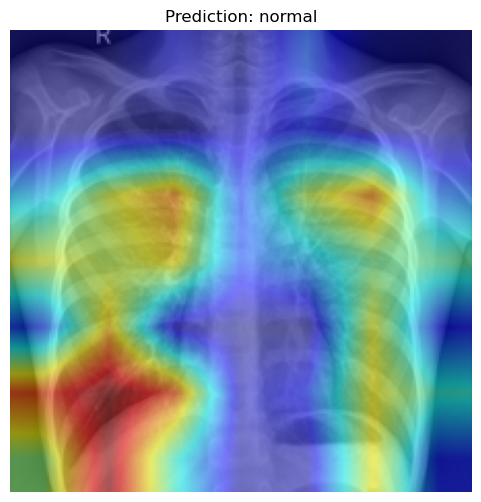

In [22]:

image_path = "C:\\Users\\senku\\OneDrive\\Desktop\\New folder\\wrong prediction\\normal chest_non_dataset.jpeg"

image_name = os.path.basename(image_path)

# Load original image
original_image = Image.open(image_path).convert("L")

# Transform for model
input_tensor = transform(original_image).unsqueeze(0)

with open("chest_xray_model(MobileNET).pkl", "rb") as f:
    pickle.load(f)

model2.eval()

#Classes
classes=['normal', 'pneumonia']

with torch.no_grad():

    output = model2(input_tensor)
    _, predicted = torch.max(output, 1)

predicted_class = classes[predicted.item()]

print("Prediction:", predicted_class)


# Grad-CAM

# Unfreeze last layer for Grad-CAM
for param in model2.features[-1].parameters():
    param.requires_grad = True
    
classes = train_dataset.classes

target_layer = model2.features[-1]

cam = GradCAM(model=model2, target_layers=[target_layer])

grayscale_cam = cam(input_tensor=input_tensor)[0]

rgb_image = np.array(original_image.resize((224,224))) / 255.0

rgb_image = np.stack([rgb_image]*3, axis=-1)

visualization = show_cam_on_image(rgb_image, grayscale_cam, use_rgb=True)

plt.figure(figsize=(6,6))
plt.imshow(visualization)
plt.title(f"Prediction: {predicted_class}")
plt.axis("off")
plt.savefig(f"sample_output_{image_name}", bbox_inches='tight')
plt.show()

In [35]:
os.makedirs("outputs", exist_ok=True)

with open("outputs/metrics.txt", "w") as f:

    f.write("Chest X-ray Classification Metrics\n")
    f.write("--------------------------------\n")

    f.write(f"Test Accuracy: {accuracy:.2f}%\n")

    f.write("Model: Pretrained MobileNet\n")

    f.write("Input Size: 224x224\n")

    f.write("Batch Size: 32\n")

    f.write("Optimizer: Adam\n")

    f.write("Loss Function: CrossEntropyLoss\n")

In [38]:
import pandas as pd
predictions = []

with torch.no_grad():

    for image_path, label in test_dataset.samples:

        # Load image
        image = Image.open(image_path).convert("L")

        # Transform
        input_tensor = transform(image).unsqueeze(0)

        # Prediction
        output = model2(input_tensor)

        _, predicted = torch.max(output, 1)

        predicted_label = classes[predicted.item()]

        # Extract filename
        image_name = image_path.split("\\")[-1]

        # Save result
        predictions.append([image_name, predicted_label])

In [39]:
df = pd.DataFrame(
    predictions,
    columns=["image_name", "label"]
)

In [40]:
df.to_csv(
    "predictions.csv",
    index=False
)

In [41]:
df.head()

,image_name,label
0,IM-0115-0001.jpeg,normal
1,IM-0177-0001.jpeg,normal
2,IM-0182-0001.jpeg,normal
3,IM-0187-0001.jpeg,normal
4,IM-0193-0001.jpeg,normal
